In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent


import data_loader as data_loader
import visualization as viz
import analysis_features as af


RAW_DIR = PROJECT_ROOT / "Data"      # raw data
PROCESSED_DIR = "Processed_data" # output
FS = 50                        # sampling rate

print(f"Current Working Directory: {Path.cwd()}")
print(f"Project Root Detected:     {PROJECT_ROOT}")
print(f"Raw data path:             {RAW_DIR}")

os.makedirs(PROCESSED_DIR, exist_ok=True)

print(":)")

Current Working Directory: /Users/louinsleung/EEN210/Xiaoye_week3_code
Project Root Detected:     /Users/louinsleung/EEN210
Raw data path:             /Users/louinsleung/EEN210/Data
:)


In [2]:
# batch processing all csv files to parquet
print(f"batch processing from '{RAW_DIR}'.")

data_loader.batch_process(RAW_DIR, PROCESSED_DIR)

print("：）Done!")


batch processing from '/Users/louinsleung/EEN210/Data'.
Found 181 CSV files in /Users/louinsleung/EEN210/Data
[Skip] FallingForwards_p1_1_35sek_20260206_113359.parquet already exists.
[Skip] FallingForwards_p1_1_35sek_20260206_113359.csv already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.parquet already exists.
[Skip] FallingForwards_p4_1_35sek_20260206_115209.csv already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.parquet already exists.
[Skip] FallingForwards_p4_2_35sek_20260206_115310.csv already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.parquet already exists.
[Skip] FallingForwards_p4_3_35sek_20260206_115411.csv already exists.
[Skip] Falling_backwards_short_P1_1_20260213_101958.parquet already exists.
[Skip] Falling_backwards_short_P1_1_20260213_101958.csv already exists.
[Skip] Falling_backwards_short_P1_2_20260213_102216.parquet already exists.
[Skip] Falling_backwards_short_P1_2_20260213_102216.csv already exists.
[Skip] Falling_bac

# data visualization
- Line plots to observe trends in acceleration and angular velocity over time.
- Scatter plots to explore relationships between features.
- Histograms to examine data distribution.

Loading representative files...
Loaded Fall (Backwards)
Loaded Cyclic ADL (Walking)
Loaded Sit-to-Stand

=== Figure 1: Time Series Trends (Line Plots) ===


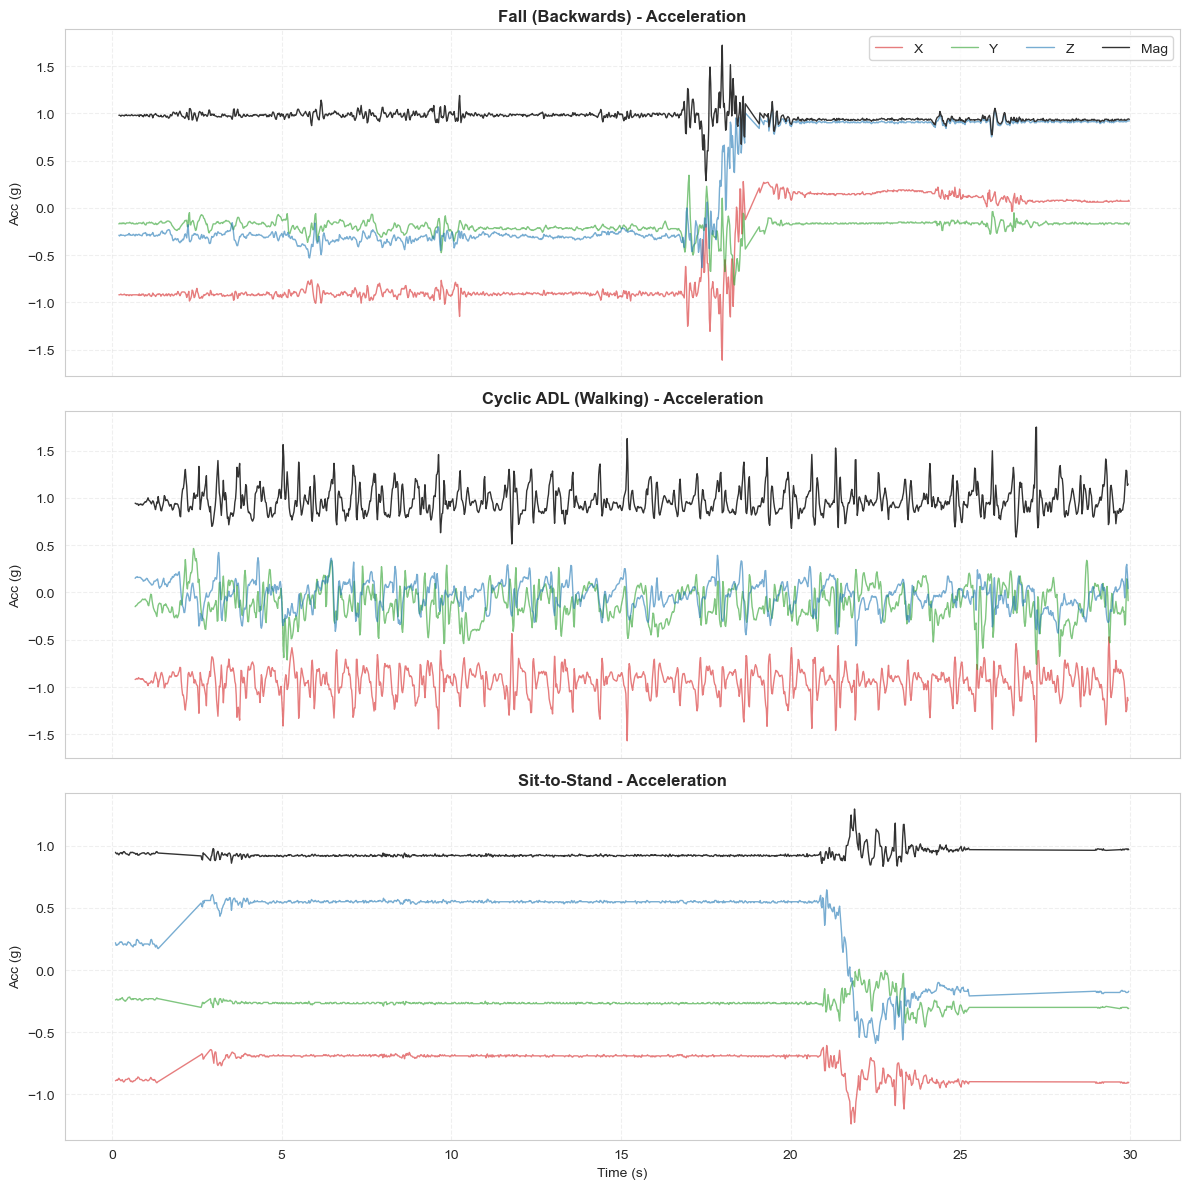

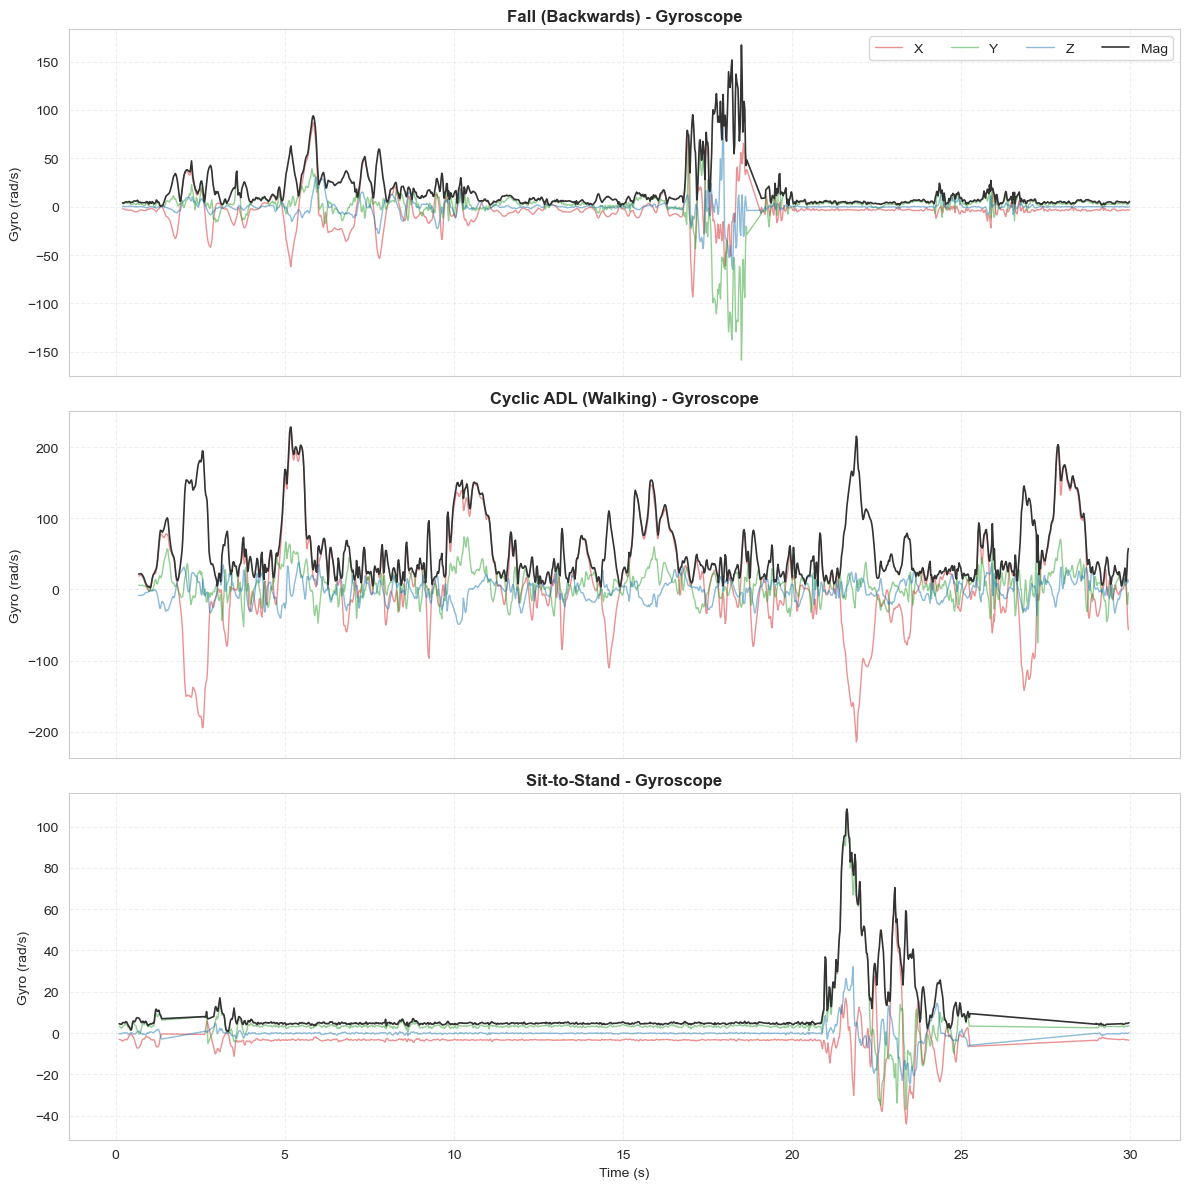


=== Figure 2: Data Distribution (Histograms) ===


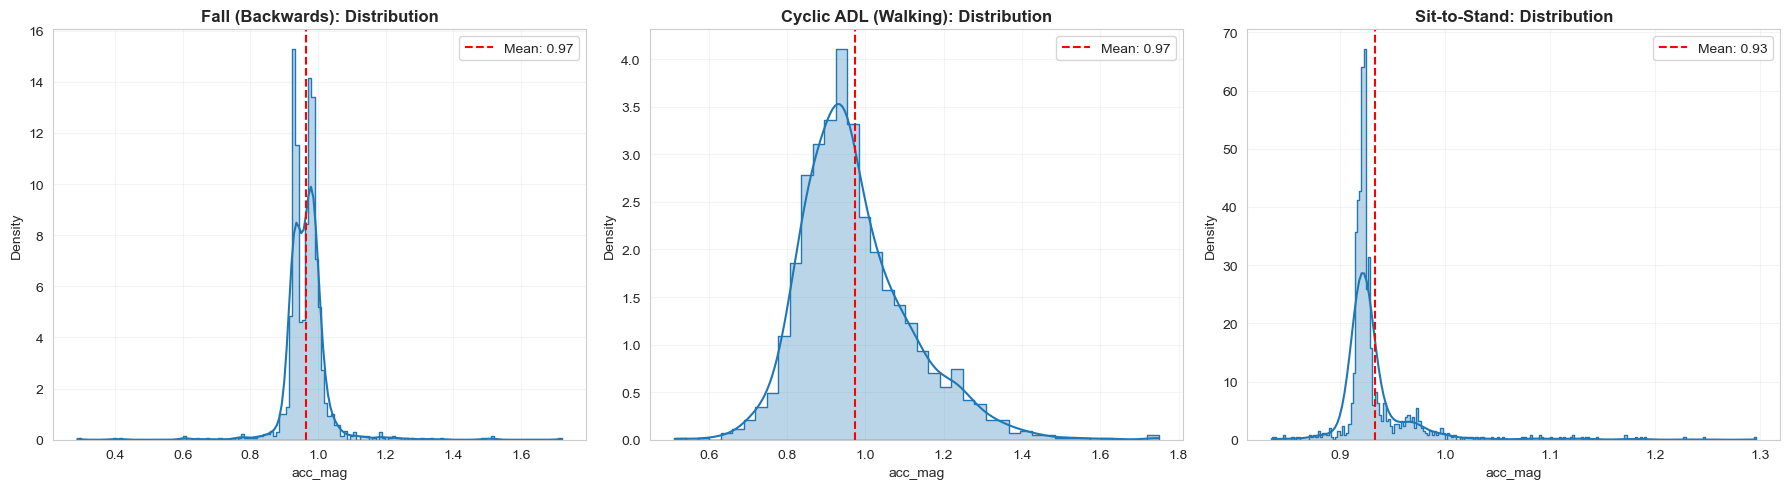


=== Figure 3: Feature Relationships (Scatter Plots) ===


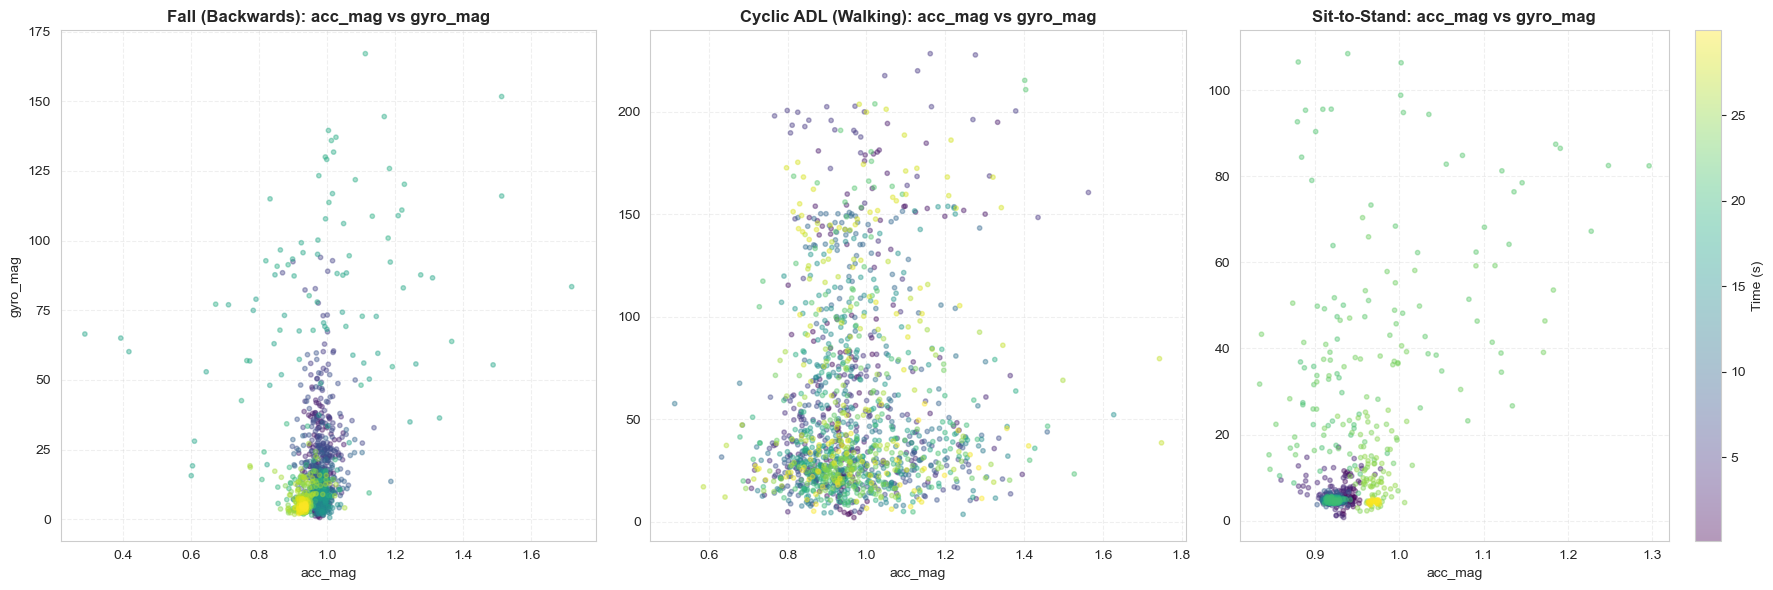

In [3]:
# raw data visualization

targets = {
    "Fall (Backwards)": "Fallingbackwards_p4_1",  
    "Cyclic ADL (Walking)": "Walking_p4_2_35sek",      
    "Sit-to-Stand": "SittingToStanding"     
}


all_files = sorted(glob.glob(os.path.join(PROCESSED_DIR, "long", "*.parquet")))
data_dict = {}


print("Loading representative files...")
for label, keyword in targets.items():
    matches = [f for f in all_files if keyword.lower() in os.path.basename(f).lower()]
    if matches:
        data_dict[label] = data_loader.load_long_parquet(matches[0])
        print(f"Loaded {label}")
    else:
        print(f" Warning: File not found for keyword '{keyword}'")


if len(data_dict) > 0:
    print("\n=== Figure 1: Time Series Trends (Line Plots) ===")
    viz.plot_raw_lines(data_dict, feature="acc_mag")
    
    print("\n=== Figure 2: Data Distribution (Histograms) ===")
    viz.plot_raw_hists(data_dict, feature="acc_mag")
    
    print("\n=== Figure 3: Feature Relationships (Scatter Plots) ===")
    viz.plot_raw_scatter(data_dict, x_col="acc_mag", y_col="gyro_mag")
else:
    print("Oh no..... No data loaded.")
  


# TSA

- loading data
- handling gaps and interpolation


Loaded 187 files.


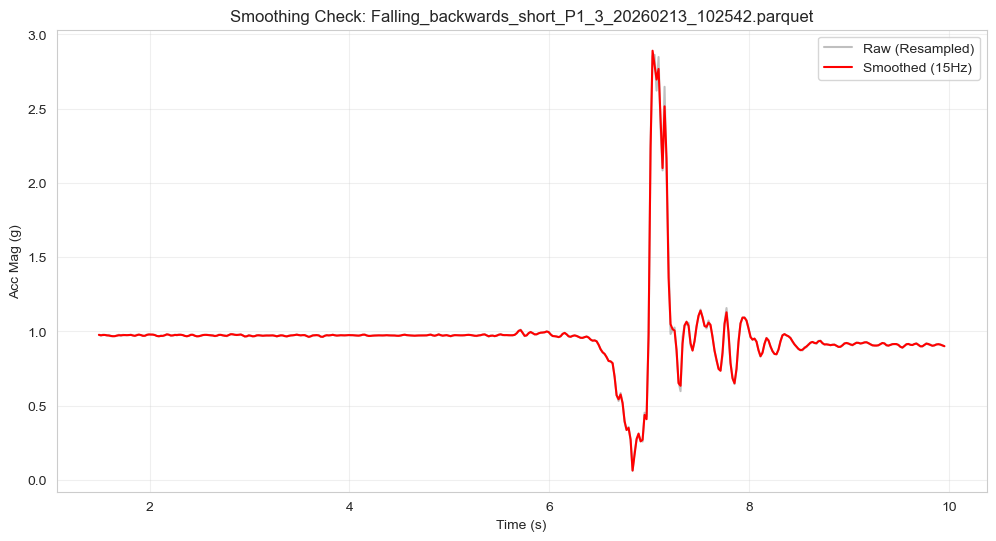

In [4]:
# smoothing
PROCESSED_DIR = "Processed_data/long" 
files = glob.glob(os.path.join(PROCESSED_DIR, "*.parquet"))


data_dict = {}
for f in files:
    data_dict[os.path.basename(f)] = pd.read_parquet(f)

print(f"Loaded {len(data_dict)} files.")

# smoothing
smoothed_data = af.apply_lowpass_filter(data_dict, cutoff=15, fs=50)

# Raw vs Smoothed
fall_files = [k for k in data_dict.keys() if "fall" in k.lower()]
if fall_files:
    sample_key = fall_files[0]
    
    raw_df = data_dict[sample_key]
    smooth_df = smoothed_data[sample_key]
    
    plt.figure(figsize=(12, 6))
    plt.plot(raw_df['t_s'], raw_df['acc_mag'], color='gray', alpha=0.5, label='Raw (Resampled)')
    plt.plot(smooth_df['t_s'], smooth_df['acc_mag'], color='red', linewidth=1.5, label='Smoothed (15Hz)')
    
    plt.title(f"Smoothing Check: {sample_key}")
    plt.xlabel("Time (s)")
    plt.ylabel("Acc Mag (g)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No fall files found to visualize.")

# Feature extraction
- Time-domain features: Mean, variance, standard deviation, skewness.
- Frequency-domain features: Spectral entropy, energy.

In [5]:

print("\nStarting feature extraction on smoothed data...")
smooth_feature_df = af.build_feature_dataset(smoothed_data, window_s=2.0, step_s=1.0, fs=50)

print(f"Extraction complete. Generated {len(smooth_feature_df)} windows.")
smooth_feature_df.head()
print("Class distribution:")
print(smooth_feature_df["activity"].value_counts())




Starting feature extraction on smoothed data...
Extraction complete. Generated 3748 windows.
Class distribution:
activity
Sit-Stand    1555
Fall         1537
Walking       656
Name: count, dtype: int64


In [6]:
smooth_feature_df.to_csv("smooth_feature_df.csv", index=False)

/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


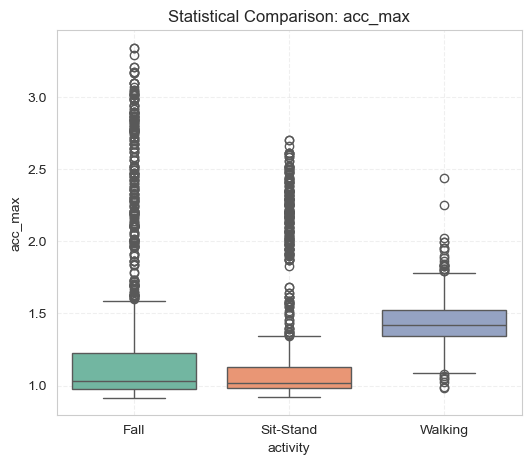

/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


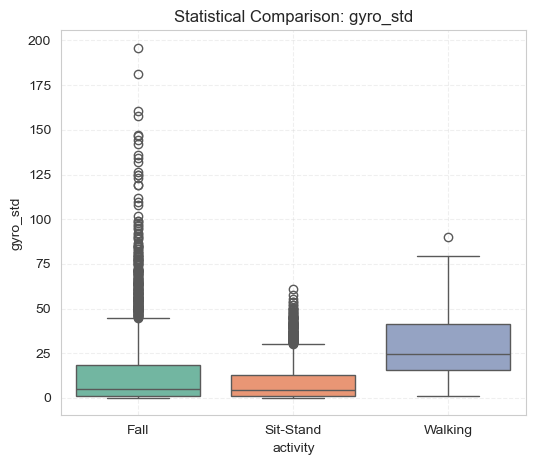

/Users/louinsleung/EEN210/Xiaoye_week3_code/visualization.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label_col, y=feature, data=df, palette="Set2")


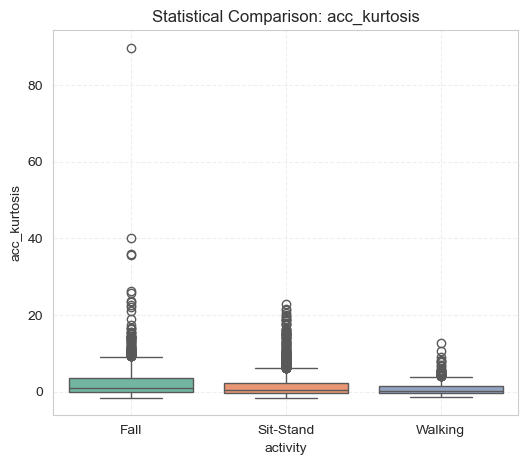

In [7]:

# check max acceleration
viz.plot_boxplot_stat(smooth_feature_df, feature="acc_max", label_col="activity")

#check Gyroscope Std
viz.plot_boxplot_stat(smooth_feature_df, feature="gyro_std", label_col="activity")

# check Kurtosis
viz.plot_boxplot_stat(smooth_feature_df, feature="acc_kurtosis", label_col="activity")


## 3D projection

Binary Class Distribution:
binary_class
Non-Fall    2211
Fall        1537
Name: count, dtype: int64

Plotting 3D Feature Space (Fall vs Non-Fall)...


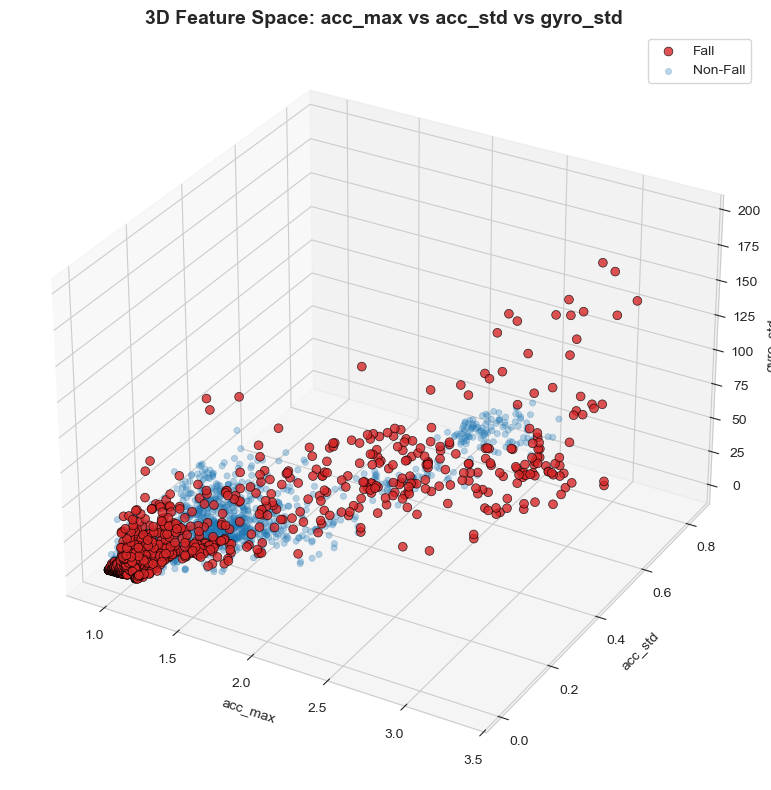

In [8]:
binary_df = smooth_feature_df.copy()

binary_df["binary_class"] = binary_df["activity"].apply(
    lambda x: "Fall" if x == "Fall" else "Non-Fall"
)

# distribution to check balance
print("Binary Class Distribution:")
print(binary_df["binary_class"].value_counts())

# Visualize in 3D
# Selected features based on previous boxplot analysis:
# - acc_max: Represents Impact Intensity
# - gyro_std: Represents Rotational Violence
# - acc_kurtosis: Represents Signal Impulsiveness (Spikiness)

print("\nPlotting 3D Feature Space (Fall vs Non-Fall)...")
viz.plot_3d_feature_space(
    binary_df, 
    x="acc_max", 
    y="acc_std", 
    z="gyro_std", 
    label_col="binary_class"
)

In [10]:
if "binary_df" not in locals():
    binary_df = smooth_feature_df.copy()
    binary_df["binary_class"] = binary_df["activity"].apply(lambda x: "Fall" if x == "Fall" else "Non-Fall")




all_features = [
    # Acceleration (acc_mag)
    "acc_max",
    "acc_mean",
    "acc_var",
    "acc_std",
    "acc_skew",
    "acc_kurtosis",
    "acc_spec_energy",
    "acc_spec_entropy",

    # Gyroscope (gyro_mag)
    "gyro_max",
    "gyro_mean",
    "gyro_var",
    "gyro_std",
    "gyro_spec_energy",
    "gyro_spec_entropy",
]


In [12]:


filtered_df = binary_df.copy()

std_threshold = 0.05 

silent_fall_indices = filtered_df[
    (filtered_df["binary_class"] == "Fall") & 
    (filtered_df["acc_std"] < std_threshold) 
].index


active_stats_df = filtered_df.drop(silent_fall_indices)


print(f"Original Windows: {len(binary_df)}")
print(f"Active Windows: {len(active_stats_df)}")
print(f"Dropped {len(silent_fall_indices)} 'silent' windows.")



Original Windows: 3748
Active Windows: 2701
Dropped 1047 'silent' windows.


# Event Segmentation
Isolate specific events from your time series, such as potential falls. Suggested methods:
- Threshold-based segmentation.
- More advanced techniques if appropriate for your data.


We used a Sliding Window Segmentation approach (Window=2s, Overlap=50%). Instead of using a hard threshold to crop events (which risks missing soft falls), we generate continuous windows and isolate fall events using a Global Peak-Centric labeling strategy. This ensures fixed input dimensions for the Random Forest model and improves robustness against sensor noise.

Visualizing Segmentation for: Falling_backwards_short_P1_1_20260213_101958.parquet


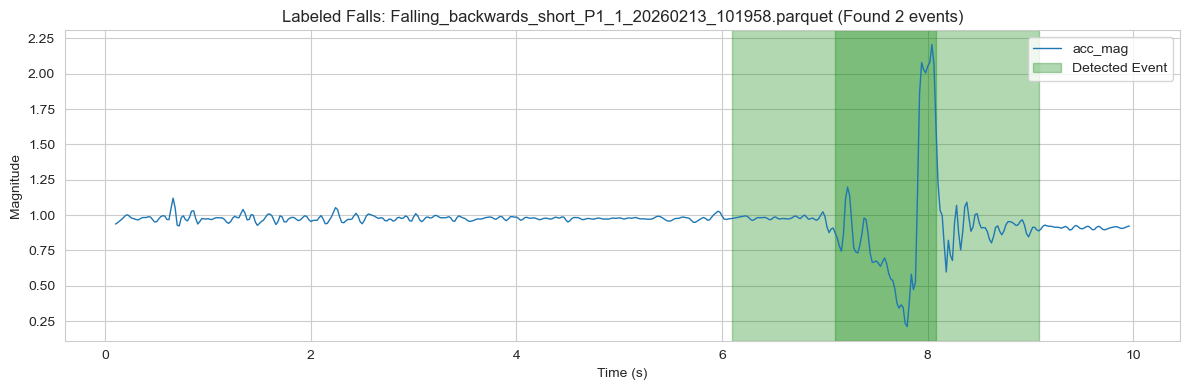

In [13]:

feature_df = pd.read_csv("smooth_feature_df.csv")


fall_files = feature_df[feature_df['label'] == 0]['file'].unique()

if len(fall_files) > 0:
    target_file = fall_files[38] 
    print(f"Visualizing Segmentation for: {target_file}")
    
    

    if target_file in smoothed_data:
        signal_df = smoothed_data[target_file]
    else:

        print("Error: File not found in smoothed_dict. Please reload data.")
        signal_df = None

    if signal_df is not None:
     
        fall_windows = feature_df[
            (feature_df['file'] == target_file) & 
            (feature_df['label'] == 1)
        ]
        
    
        events = list(zip(fall_windows['t_start'], fall_windows['t_end']))
        
        viz.plot_segmentation(signal_df, events, title=f"Labeled Falls: {target_file}")
        
else:
    print("No Fall samples found in the dataset.")

# Model


In [14]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, recall_score, precision_score

In [15]:
csv_path = "smooth_feature_df.csv"
df = pd.read_csv(csv_path)

print(f" Shape: {df.shape}")
print("Class distribution:\n", df['label'].value_counts())

 Shape: (3748, 17)
Class distribution:
 label
0    3587
1     161
Name: count, dtype: int64


In [16]:
metadata_cols = ['file', 'label', 'activity',  't_start', 't_end', 'binary_class', 'seg_id']

feature_cols = [c for c in df.columns if c not in metadata_cols]

X = df[feature_cols].select_dtypes(include=[np.number])
y = df['label']
groups = df['file']
print(f"\nTraining with {len(X.columns)} features:")
print(list(X.columns))


Training with 12 features:
['acc_max', 'acc_mean', 'acc_std', 'gyro_max', 'gyro_mean', 'gyro_std', 'acc_skew', 'acc_kurtosis', 'acc_spec_energy', 'acc_spec_entropy', 'gyro_spec_energy', 'gyro_spec_entropy']


In [20]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,      
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [21]:
cv = StratifiedGroupKFold(n_splits=5)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'average_precision']

scores = cross_validate(rf_model, X, y, groups=groups, cv=cv, scoring=scoring)

print("\n=== Cross-Validation Report (Average) ===")
print(f"Accuracy:  {scores['test_accuracy'].mean():.4f} (+/- {scores['test_accuracy'].std():.2f})")
print(f"Precision: {scores['test_precision'].mean():.4f} (+/- {scores['test_precision'].std():.2f})")
print(f"Recall:    {scores['test_recall'].mean():.4f}    (+/- {scores['test_recall'].std():.2f})")
print(f"F1 Score:  {scores['test_f1'].mean():.4f}    (+/- {scores['test_f1'].std():.2f})")
print(f"ROC AUC:   {scores['test_roc_auc'].mean():.4f}    (+/- {scores['test_roc_auc'].std():.2f})")
print(f"Avg Precision-Recall AUC: {scores['test_average_precision'].mean():.4f}    (+/- {scores['test_average_precision'].std():.2f})")

print("\n=== Cross-Validation Fold Details ===")

for i, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups)):
    print(f"Fold {i}:")
    print(f"  Train: Fall={y.iloc[train_idx].sum()}, Total={len(train_idx)}")
    print(f"  Test:  Fall={y.iloc[test_idx].sum()}, Total={len(test_idx)}")


=== Cross-Validation Report (Average) ===
Accuracy:  0.9789 (+/- 0.01)
Precision: 0.7396 (+/- 0.12)
Recall:    0.8440    (+/- 0.05)
F1 Score:  0.7807    (+/- 0.06)
ROC AUC:   0.9737    (+/- 0.01)
Avg Precision-Recall AUC: 0.8436    (+/- 0.04)

=== Cross-Validation Fold Details ===
Fold 0:
  Train: Fall=128, Total=3000
  Test:  Fall=33, Total=748
Fold 1:
  Train: Fall=130, Total=2999
  Test:  Fall=31, Total=749
Fold 2:
  Train: Fall=128, Total=2998
  Test:  Fall=33, Total=750
Fold 3:
  Train: Fall=129, Total=2998
  Test:  Fall=32, Total=750
Fold 4:
  Train: Fall=129, Total=2997
  Test:  Fall=32, Total=751


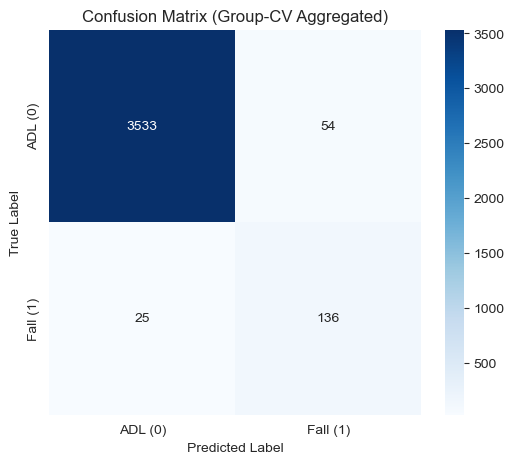

In [22]:
import seaborn as sns
# confusion matrix
y_pred_cv = cross_val_predict(rf_model, X, y, groups=groups, cv=cv, n_jobs=-1)


cm = confusion_matrix(y, y_pred_cv)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['ADL (0)', 'Fall (1)'], 
            yticklabels=['ADL (0)', 'Fall (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Group-CV Aggregated)')
plt.show()

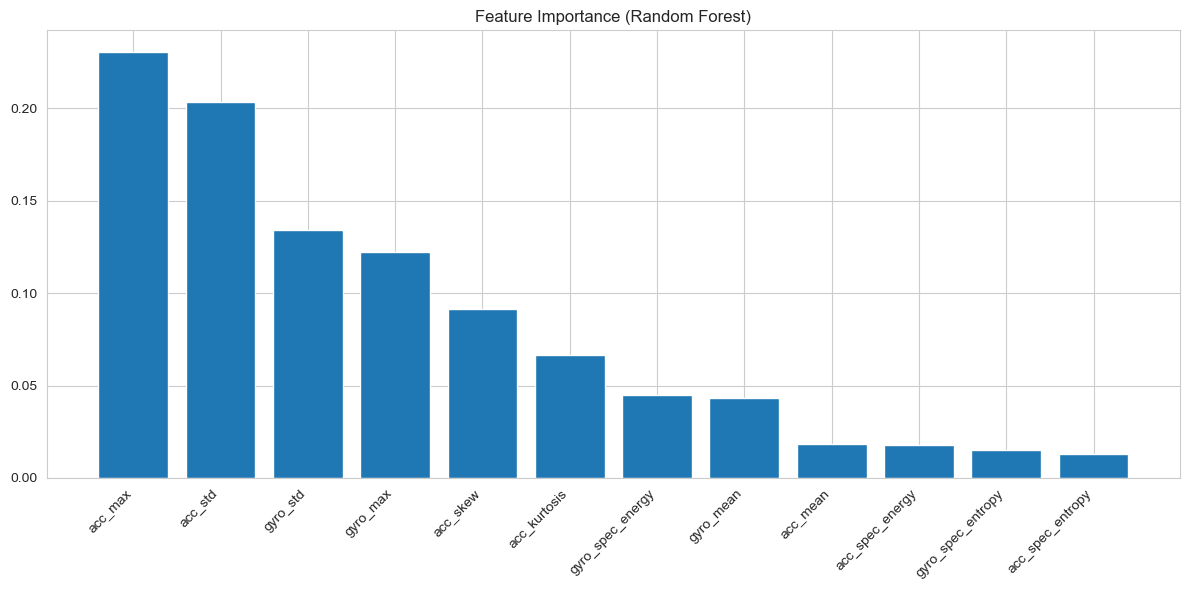


Top 5 important features:
1. acc_max (0.2306)
2. acc_std (0.2034)
3. gyro_std (0.1339)
4. gyro_max (0.1223)
5. acc_skew (0.0912)


In [23]:
rf_model.fit(X, y)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("\nTop 5 important features:")
for i in range(5):
    print(f"{i+1}. {X.columns[indices[i]]} ({importances[indices[i]]:.4f})")

/opt/anaconda3/envs/een210/lib/python3.10/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Global AUC Score: 0.9659


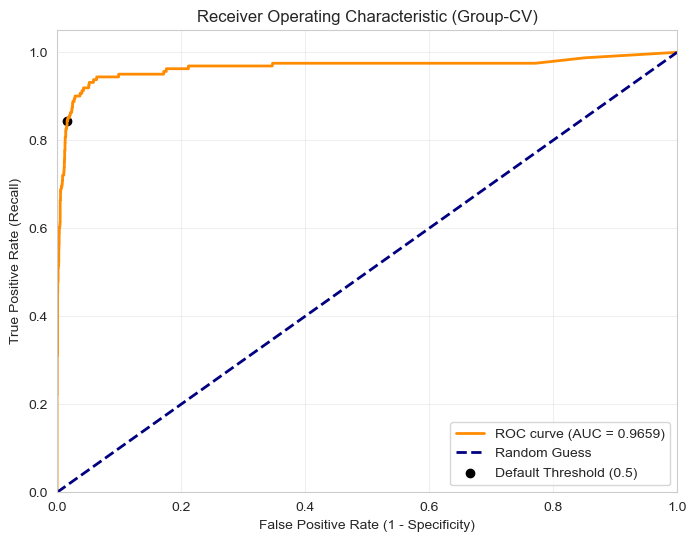


--- Optimization Strategy ---
Current Performance at Threshold=0.50: Recall ≈ 0.8447
To achieve Recall >= 0.9:
 -> Need to lower threshold to: 0.2859
 -> Expected False Positive Rate: 0.0290


In [24]:
# roc
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.model_selection import cross_val_predict


y_probas = cross_val_predict(rf_model,X,y,groups=groups, method='predict_proba',n_jobs=-1)
y_scores = y_probas[:, 1]


fpr, tpr, thresholds = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print(f"Global AUC Score: {roc_auc:.4f}")


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')


import numpy as np

close_default_index = np.argmin(np.abs(thresholds - 0.5))

plt.scatter(fpr[close_default_index], tpr[close_default_index], marker='o', color='black', label='Default Threshold (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (Group-CV)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()



target_recall = 0.90
idx = next(i for i, v in enumerate(tpr) if v >= target_recall)


print(f"\n--- Optimization Strategy ---")
print(f"Current Performance at Threshold=0.50: Recall ≈ {tpr[close_default_index]:.4f}")
print(f"To achieve Recall >= {target_recall}:")
print(f" -> Need to lower threshold to: {thresholds[idx]:.4f}")
print(f" -> Expected False Positive Rate: {fpr[idx]:.4f}")



Average Precision (PR AUC): 0.8323


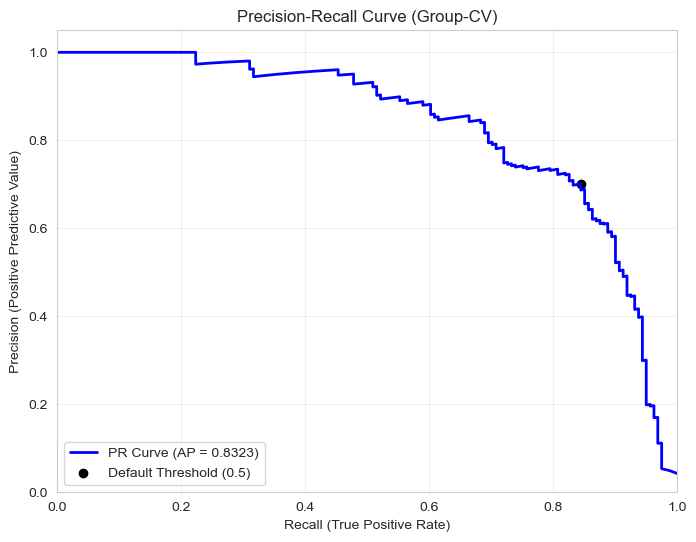


--- PR Optimization Strategy ---
To achieve Recall >= 0.9:
  -> Threshold: 0.2859
  -> Precision will drop to: 0.5823


In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score



precisions, recalls, pr_thresholds = precision_recall_curve(y, y_scores)
pr_auc = average_precision_score(y, y_scores)

print(f"Average Precision (PR AUC): {pr_auc:.4f}")


plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', lw=2, label=f'PR Curve (AP = {pr_auc:.4f})')


close_default_pr = np.argmin(np.abs(pr_thresholds - 0.5))
plt.scatter(recalls[close_default_pr], precisions[close_default_pr], 
            marker='o', color='black', label='Default Threshold (0.5)')


plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve (Group-CV)')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()


target_recall = 0.90

idx_pr = np.where(recalls >= target_recall)[0][-1] 

print(f"\n--- PR Optimization Strategy ---")
print(f"To achieve Recall >= {target_recall}:")
print(f"  -> Threshold: {pr_thresholds[idx_pr]:.4f}")
print(f"  -> Precision will drop to: {precisions[idx_pr]:.4f}")


=== Re-evaluating with Optimized Threshold: 0.4 ===
              precision    recall  f1-score   support

         ADL       0.99      0.98      0.99      3587
        Fall       0.65      0.86      0.74       161

    accuracy                           0.97      3748
   macro avg       0.82      0.92      0.86      3748
weighted avg       0.98      0.97      0.98      3748



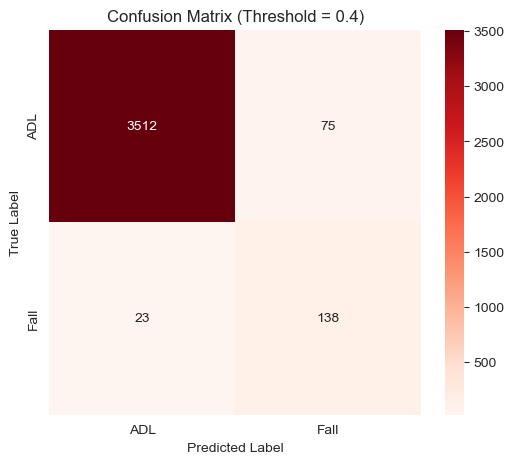

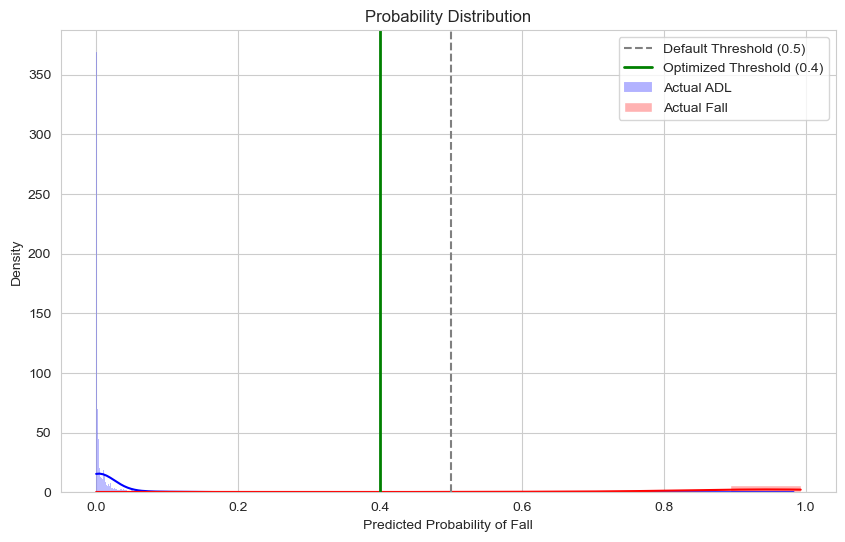

In [28]:
OPTIMAL_THRESHOLD = 0.4

print(f"\n=== Re-evaluating with Optimized Threshold: {OPTIMAL_THRESHOLD} ===")


y_scores = y_probas[:, 1]

y_pred_opt = (y_scores >= OPTIMAL_THRESHOLD).astype(int)


print(classification_report(y, y_pred_opt, target_names=['ADL', 'Fall']))


cm_opt = confusion_matrix(y, y_pred_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['ADL', 'Fall'], 
            yticklabels=['ADL', 'Fall'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Threshold = {OPTIMAL_THRESHOLD})')
plt.show()



plt.figure(figsize=(10, 6))


sns.histplot(y_scores[y==0], color='blue', label='Actual ADL', kde=True, stat="density", alpha=0.3)

sns.histplot(y_scores[y==1], color='red', label='Actual Fall', kde=True, stat="density", alpha=0.3)

plt.axvline(0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
plt.axvline(OPTIMAL_THRESHOLD, color='green', linewidth=2, label=f'Optimized Threshold ({OPTIMAL_THRESHOLD})')

plt.xlabel('Predicted Probability of Fall')
plt.ylabel('Density')
plt.title('Probability Distribution')
plt.legend()
plt.show()

In [29]:
import joblib

bundle = {
    "model": rf_model,
    "feature_cols": list(X.columns)
}

joblib.dump(bundle, "Old_model.joblib")
print("Saved model bundle with feature columns:", len(bundle["feature_cols"]))

Saved model bundle with feature columns: 12
